# Taller de análisis de sentimientos y procesamiento de texto

Utilizando la base de datos archive.csv que contiene mensajes financieros.

Se debe realizar el análisis de sentimientos de los mensajes. Para lo cual se debe hacer lo siguiente

Procesamiento del texto
- Limpieza de caracteres
- Eliminación de stopwords

Análisis de sentimientos con TextBlob
Presentar un breve reporte del análisis de sentimientos

Explorar otro método de análisis de sentimientos y compararlo con lo obtenido en el punto anterior.


In [37]:
import pandas as pd
from textblob import TextBlob
import csv
import re
import time
import string

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
df = pd.read_csv('/content/drive/MyDrive/Colab aprendizaje no supervisado/Taller analisis sentimientos/archive.csv')
df.head(3)

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive


# Limpieza de caracteres

In [40]:
def clean_text(text):
  text = re.sub(r'^RT[\s]+', '', text)
  text = re.sub(r'https?:\/\/.*[\r\n]*', '', text)
  text = re.sub(r'#', '', text)
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  return text

In [41]:
df['clean_text'] = df['Sentence'].apply(clean_text)

In [42]:
df['clean_text']

,clean_text
0,The GeoSolutions technology will leverage Bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po..."
2,"For the last quarter of 2010 , Componenta 's n..."
3,According to the Finnish-Russian Chamber of Co...
4,The Swedish buyout firm has sold its remaining...
...,...
5837,RISING costs have forced packaging producer Hu...
5838,Nordic Walking was first used as a summer trai...
5839,"According shipping company Viking Line , the E..."
5840,"In the building and home improvement trade , s..."


In [43]:
import re

def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticones
                           u"\U0001F300-\U0001F5FF"  # simbolos & pictogramas
                           u"\U0001F680-\U0001F6FF"  # simbolos de mapas y transporte
                           u"\U0001F1E0-\U0001F1FF"  # banderas (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['clean_text'] = df['clean_text'].apply(remove_emojis)

In [44]:
df['clean_text']

,clean_text
0,The GeoSolutions technology will leverage Bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po..."
2,"For the last quarter of 2010 , Componenta 's n..."
3,According to the Finnish-Russian Chamber of Co...
4,The Swedish buyout firm has sold its remaining...
...,...
5837,RISING costs have forced packaging producer Hu...
5838,Nordic Walking was first used as a summer trai...
5839,"According shipping company Viking Line , the E..."
5840,"In the building and home improvement trade , s..."


# Quitar stopwords

In [46]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

# Create a new DataFrame called df1
df1 = pd.DataFrame()
# Assign the clean_text_no_stopwords column to the new DataFrame
df1['clean_text_no_stopwords'] = df['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Polaridad con stopwords

In [47]:
def get_polarity(text):
  analysis = TextBlob(text).sentiment
  return analysis.polarity

In [48]:
df['polarity'] = df['clean_text'].apply(get_polarity)

In [49]:
df['polarity'].head(3)

,polarity
0,0.209091
1,0.022222
2,0.000000


In [50]:
df[df.polarity < 0.3][['Sentence', 'polarity']].head()

,Sentence,polarity
0,The GeoSolutions technology will leverage Bene...,0.209091
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",0.022222
2,"For the last quarter of 2010 , Componenta 's n...",0.000000
3,According to the Finnish-Russian Chamber of Co...,0.062500
4,The Swedish buyout firm has sold its remaining...,-0.100000


In [51]:
def x_range(x):
  if x > 0:
    return 1
  elif x == 0:
    return 0
  else:
    return -1

In [52]:
df['result'] = df['polarity'].apply(x_range)

In [53]:
df.head(3)

,Sentence,Sentiment,clean_text,polarity,result
0,The GeoSolutions technology will leverage Bene...,positive,The GeoSolutions technology will leverage Bene...,0.209091,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"$ESI on lows, down $1.50 to $2.50 BK a real po...",0.022222,1
2,"For the last quarter of 2010 , Componenta 's n...",positive,"For the last quarter of 2010 , Componenta 's n...",0.000000,0


In [54]:
df['result'].value_counts()

,count
result,
0,2995
1,1798
-1,1049


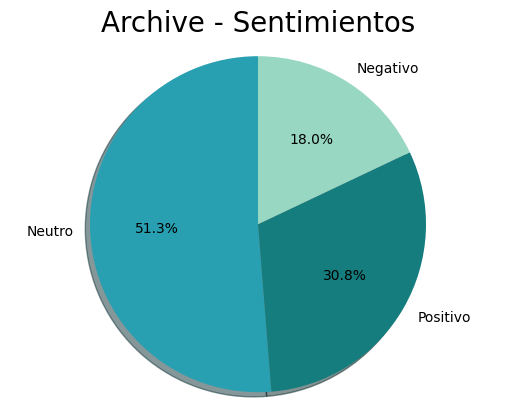

In [55]:
import matplotlib.pyplot as plt
labels = 'Neutro', 'Positivo', 'Negativo'
colors = ['#29A0B1','#167D7F','#98D7C2']
plt.pie(df['result'].value_counts(), labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)
plt.title('Archive - Sentimientos', fontsize = 20)
plt.axis('equal')
plt.show()

# Wordcloud con stopwords

In [56]:
from wordcloud import WordCloud
text = ' '.join(df.clean_text)
text

'The GeoSolutions technology will leverage Benefon \'s GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model . $ESI on lows, down $1.50 to $2.50 BK a real possibility For the last quarter of 2010 , Componenta \'s net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m . According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia . The Swedish buyout firm has sold its remaining 22.4 percent stake , almost eighteen months after taking the company public in Finland . $SPY wouldn\'t be surprised to see a green close Shell\'s $70 Billion BG Deal Meets Shareholder Skepticism SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANGE RELEASE OCTOBER 14 , 2008 AT 2:45 PM The Company updates its full year outlook and estimates its results to 

In [57]:
wordcloud = WordCloud(width=1024, height=800, colormap='Blues', min_font_size=14).generate(text)

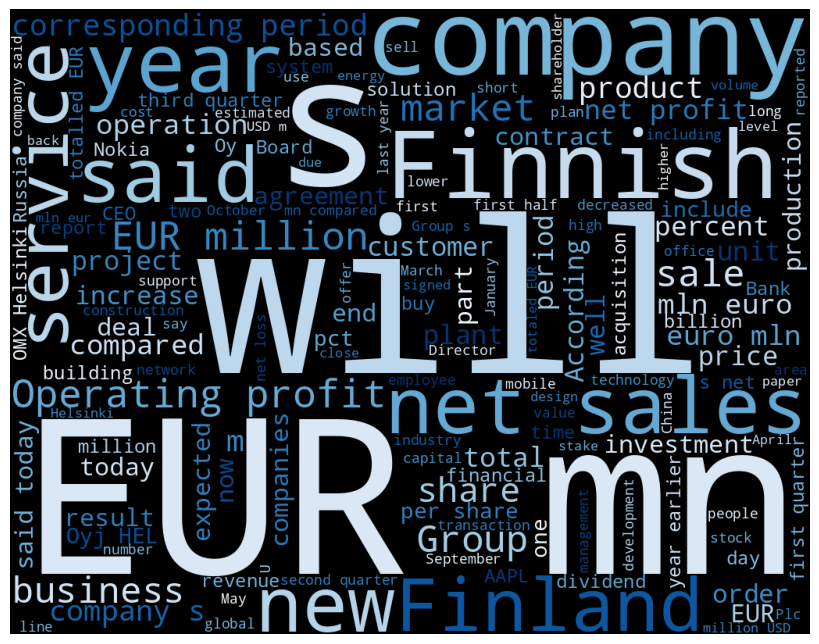

In [58]:
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

# Polaridad sin stopwords

In [59]:
df1['clean_text_no_stopwords']

,clean_text_no_stopwords
0,GeoSolutions technology leverage Benefon 's GP...
1,"$ESI lows, $1.50 $2.50 BK real possibility"
2,"last quarter 2010 , Componenta 's net sales do..."
3,"According Finnish-Russian Chamber Commerce , m..."
4,Swedish buyout firm sold remaining 22.4 percen...
...,...
5837,RISING costs forced packaging producer Huhtama...
5838,Nordic Walking first used summer training meth...
5839,"According shipping company Viking Line , EU de..."
5840,"building home improvement trade , sales decrea..."


In [60]:
df1['polarity_no_stopwords'] = df1['clean_text_no_stopwords'].apply(get_polarity)

In [61]:
df1['polarity_no_stopwords'].head(3)

,polarity_no_stopwords
0,0.209091
1,0.200000
2,0.000000


In [64]:
df1[df1.polarity_no_stopwords < 0.3][['clean_text_no_stopwords', 'polarity_no_stopwords']].head()

,clean_text_no_stopwords,polarity_no_stopwords
0,GeoSolutions technology leverage Benefon 's GP...,0.209091
1,"$ESI lows, $1.50 $2.50 BK real possibility",0.200000
2,"last quarter 2010 , Componenta 's net sales do...",0.000000
3,"According Finnish-Russian Chamber Commerce , m...",0.062500
4,Swedish buyout firm sold remaining 22.4 percen...,-0.100000


In [65]:
def x_range(x):
  if x > 0:
    return 1
  elif x == 0:
    return 0
  else:
    return -1

In [66]:
df1['result'] = df1['polarity_no_stopwords'].apply(x_range)

In [67]:
df1.head(3)

,clean_text_no_stopwords,polarity_no_stopwords,result
0,GeoSolutions technology leverage Benefon 's GP...,0.209091,1
1,"$ESI lows, $1.50 $2.50 BK real possibility",0.200000,1
2,"last quarter 2010 , Componenta 's net sales do...",0.000000,0


In [68]:
df1['result'].value_counts()

,count
result,
0,3254
1,1714
-1,874


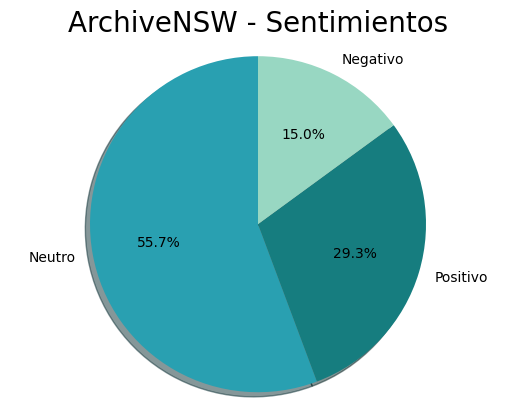

In [70]:
import matplotlib.pyplot as plt
labels = 'Neutro', 'Positivo', 'Negativo'
colors = ['#29A0B1','#167D7F','#98D7C2']
plt.pie(df1['result'].value_counts(), labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)
plt.title('ArchiveNSW - Sentimientos', fontsize = 20)
plt.axis('equal')
plt.show()

# Wordcloud sin wordstop

In [71]:
from wordcloud import WordCloud
text = ' '.join(df1.clean_text_no_stopwords)
text

'GeoSolutions technology leverage Benefon \'s GPS solutions providing Location Based Search Technology , Communities Platform , location relevant multimedia content new powerful commercial model . $ESI lows, $1.50 $2.50 BK real possibility last quarter 2010 , Componenta \'s net sales doubled EUR131m EUR76m period year earlier , moved zero pre-tax profit pre-tax loss EUR7m . According Finnish-Russian Chamber Commerce , major construction companies Finland operating Russia . Swedish buyout firm sold remaining 22.4 percent stake , almost eighteen months taking company public Finland . $SPY surprised see green close Shell\'s $70 Billion BG Deal Meets Shareholder Skepticism SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANGE RELEASE OCTOBER 14 , 2008 2:45 PM Company updates full year outlook estimates results remain loss full year . Kone \'s net sales rose 14 % year-on-year first nine months 2008 . Stockmann department store total floor space 8,000 square metres Stockmann \'s investment project

In [72]:
wordcloud = WordCloud(width=1024, height=800, colormap='Blues', min_font_size=14).generate(text)

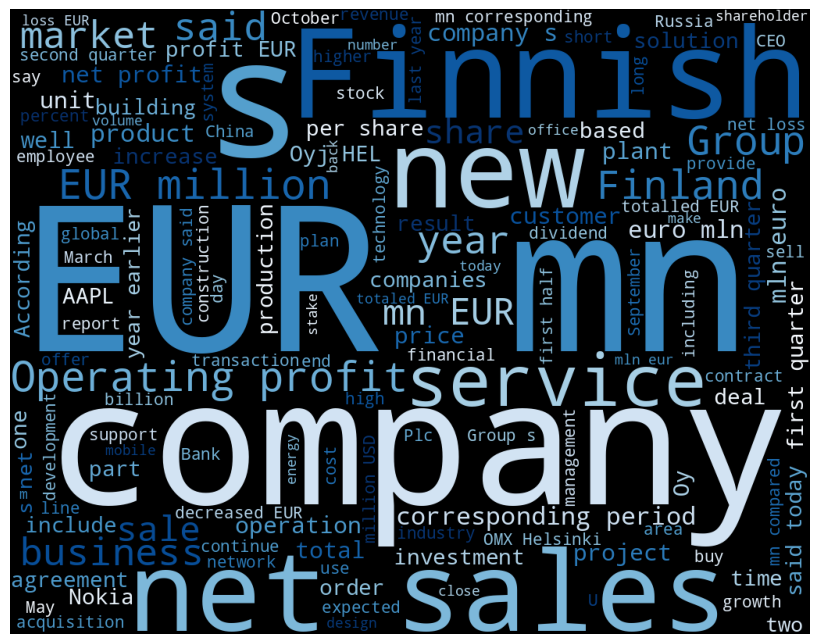

In [73]:
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

# Análisis

Con el método de textblob se realizó el análisis con stopwords y sin stopwords.



*   Con stopwords: Poco más del 50% son consideradas frases neutras, con menos del 20% consideradas negativas, sin eliminar los stopwords la palabra más usada es un stopword (will) junto al diminutivo de la divisa europea (EUR).
*   Sin stopwords: Tras eliminar los stopwords, el porcentaje de frases neutras aumentan y el de frases negativas disminuyen, el porcentaje de frases positivas también disminuyen pero en menor medida, las palabras más usadas serían company, EUR y Finnish.



# Otro método

In [74]:
pip install nltk

In [75]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [76]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [77]:
sia = SentimentIntensityAnalyzer()

In [78]:
def analyze_sentiment(text):
    scores = sia.polarity_scores(text)
    return scores

# Aplicar el análisis de sentimientos
df1['sentiment_scores'] = df1['clean_text_no_stopwords'].apply(analyze_sentiment)

# Separar las puntuaciones en columnas individuales
df1[['neg', 'neu', 'pos', 'compound']] = df1['sentiment_scores'].apply(pd.Series)

# Clasificación del sentimiento
df1['sentiment'] = df1['compound'].apply(lambda x: 'positivo' if x > 0.05 else ('negativo' if x < -0.05 else 'neutral'))

In [79]:
print(df1[['clean_text_no_stopwords', 'neg', 'neu', 'pos', 'compound', 'sentiment']])

                                clean_text_no_stopwords    neg    neu    pos  \
0     GeoSolutions technology leverage Benefon 's GP...  0.000  0.816  0.184   
1            $ESI lows, $1.50 $2.50 BK real possibility  0.231  0.769  0.000   
2     last quarter 2010 , Componenta 's net sales do...  0.099  0.776  0.125   
3     According Finnish-Russian Chamber Commerce , m...  0.000  1.000  0.000   
4     Swedish buyout firm sold remaining 22.4 percen...  0.000  1.000  0.000   
...                                                 ...    ...    ...    ...   
5837  RISING costs forced packaging producer Huhtama...  0.306  0.694  0.000   
5838  Nordic Walking first used summer training meth...  0.000  1.000  0.000   
5839  According shipping company Viking Line , EU de...  0.000  0.833  0.167   
5840  building home improvement trade , sales decrea...  0.000  0.750  0.250   
5841  HELSINKI AFX - KCI Konecranes said order four ...  0.000  1.000  0.000   

      compound sentiment  
0       0.54

In [81]:
sentiment_counts = df1['sentiment'].value_counts()
sentiment_counts

,count
sentiment,
positivo,2691
neutral,2441
negativo,710


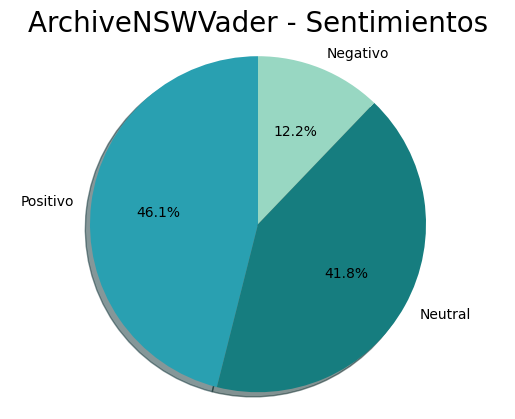

In [82]:
import matplotlib.pyplot as plt
labels = 'Positivo', 'Neutral', 'Negativo'
colors = ['#29A0B1','#167D7F','#98D7C2']
plt.pie(df1['sentiment'].value_counts(), labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)
plt.title('ArchiveNSWVader - Sentimientos', fontsize = 20)
plt.axis('equal')
plt.show()

# Análisis

Con el método Vader el porcentaje de cada tipo de frase cambia, las neutras disminuyen hasta un nivel inferior al 50% y las positivas aumentan hasta superar las frases neutras, las frases negativas disminuyen aún más.